# 🔧 Setup and Initialization

In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import time
import random
import pandas as pd
from sklearn.manifold import TSNE
from IPython.display import clear_output

In [26]:
# Set random seeds for reproducibility
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

In [27]:
# Check if CUDA is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


# 📦 CIFAR-10 Dataset Loading

In [28]:
def get_cifar10_loaders(batch_size=128):
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])

    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])

    trainset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)

    testset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
    testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

    return trainloader, testloader

# 🧱 Model Architectures

## MLP Baseline

In [29]:
# Model definitions
class BasicBlock(nn.Module):
    """
    A base class for all residual block variants to be implemented
    """
    def __init__(self, in_channels, out_channels, stride=1, skip_type='additive'):
        super(BasicBlock, self).__init__()
        self.skip_type = skip_type

        # Main path
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # Skip-connection handling
        self.stride = stride
        self.in_channels = in_channels
        self.out_channels = out_channels

        # Shortcut for dimension matching when channels change
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.shortcut = nn.Identity()

        # Extra components for different skip-connection types
        if skip_type == 'gated':
            # For gated skip - learnable gate
            self.gate = nn.Sequential(
                nn.Conv2d(out_channels, out_channels, kernel_size=1, bias=True),
                nn.Sigmoid()
            )
        elif skip_type == 'learned_scalar':
            # Learnable scalar for skip
            self.alpha = nn.Parameter(torch.ones(1))
        elif skip_type == 'concatenative':
            # For concatenative skip - additional 1x1 conv to match dimensions
            self.concat_proj = nn.Conv2d(out_channels + out_channels, out_channels, kernel_size=1, bias=False)
        elif skip_type == 'droppath':
            # Dropout rate for skip path
            self.drop_prob = 0.2

    def forward(self, x):
        # Main path
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        # Skip path handling based on type
        skip = self.shortcut(x)

        if self.skip_type == 'additive':
            # Standard ResNet skip-connection
            out = out + skip

        elif self.skip_type == 'gated':
            # Gated skip: multiply skip with learned gate
            gate_value = self.gate(skip)
            out = out + gate_value * skip

        elif self.skip_type == 'learned_scalar':
            # Learned scalar skip
            out = out + self.alpha * skip

        elif self.skip_type == 'concatenative':
            # Concatenative skip (DenseNet style)
            out = torch.cat([out, skip], dim=1)
            out = self.concat_proj(out)

        elif self.skip_type == 'quadratic':
            # Quadratic skip path
            out = out + skip + skip**2
            quad_skip = torch.clamp(skip * skip, min=-3.0, max=3.0)
            out = out + skip + quad_skip

        elif self.skip_type == 'relu_skip':
            # ReLU-activated skip path
            out = out + F.relu(skip)

        elif self.skip_type == 'droppath':
            # DropPath skip: randomly drop the skip path during training
            if self.training:
                mask = (torch.rand(skip.shape[0], 1, 1, 1, device=skip.device) > self.drop_prob).float()
                out = out + mask * skip
            else:
                out = out + (1 - self.drop_prob) * skip

        elif self.skip_type == 'zeroskip':
            # No skip connection (ablation)
            pass
            out = out

        # Final activation
        out = F.relu(out)
        return out

## ResNet Model  

In [30]:
class ResNetModel(nn.Module):
    """
    Generic ResNet model that can incorporate different skip connection variants
    """
    def __init__(self, block, num_blocks, skip_type='additive', num_classes=10):
        super(ResNetModel, self).__init__()
        self.in_planes = 64
        self.skip_type = skip_type

        # Initial convolutional layer
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)

        # Residual blocks
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)

        # Final classifier
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_planes, planes, stride, self.skip_type))
            self.in_planes = planes
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)

        # Global average pooling and classification
        out = self.avg_pool(out)
        features = torch.flatten(out, 1)
        out = self.fc(features)
        return out, features

In [31]:
# MLP baseline without skip connections
class MLP(nn.Module):
    def __init__(self, num_layers=5, hidden_dim=512, num_classes=10):
        super(MLP, self).__init__()
        self.flatten = nn.Flatten()

        # Input layer
        layers = [nn.Linear(3*32*32, hidden_dim), nn.ReLU()]

        # Hidden layers
        for _ in range(num_layers - 2):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.ReLU())

        # Output layer
        layers.append(nn.Linear(hidden_dim, num_classes))

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        x = self.flatten(x)
        features = x  # For feature extraction (not very meaningful for MLP)
        out = self.model(x)
        return out, features

## Model Creation Factory

In [32]:
# Function to create models
def create_model(model_type='resnet', skip_type='additive', num_layers=5):
    if model_type == 'resnet':
        # ResNet-18 configuration
        return ResNetModel(BasicBlock, [2, 2, 2, 2], skip_type=skip_type)
    elif model_type == 'mlp':
        # MLP baseline
        return MLP(num_layers=num_layers)
    else:
        raise ValueError("Unknown model type")

# ⚙️ Training Utilities

## Training Loop  

In [33]:
# Training and evaluation functions
def train_epoch(model, train_loader, criterion, optimizer, device, epoch, log_interval=5, track_gradients=False):
    model.train()
    train_loss = 0
    correct = 0
    total = 0
    grad_norms = [] if track_gradients else None

    with tqdm(train_loader, desc=f"Epoch {epoch}", leave=False) as pbar:
        for batch_idx, (inputs, targets) in enumerate(pbar):
            inputs, targets = inputs.to(device), targets.to(device)

            optimizer.zero_grad()
            outputs, _ = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()

            # Track gradient norms if requested
            if track_gradients and batch_idx % log_interval == 0:
                total_norm = 0
                for p in model.parameters():
                    if p.grad is not None:
                        param_norm = p.grad.data.norm(2)
                        total_norm += param_norm.item() ** 2
                total_norm = total_norm ** 0.5
                grad_norms.append(total_norm)

            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

            # Update progress bar
            pbar.set_postfix({
                'loss': train_loss/(batch_idx+1),
                'acc': 100.*correct/total
            })

    return train_loss/len(train_loader), 100.*correct/total, grad_norms

## Evaluation

In [34]:
def evaluate(model, test_loader, criterion, device, return_features=False):
    model.eval()
    test_loss = 0
    correct = 0
    total = 0
    all_features = []
    all_targets = []

    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs, features = model(inputs)
            loss = criterion(outputs, targets)

            test_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

            if return_features:
                all_features.append(features.cpu().numpy())
                all_targets.append(targets.cpu().numpy())

    if return_features:
        all_features = np.concatenate(all_features, axis=0)
        all_targets = np.concatenate(all_targets, axis=0)
        return test_loss/len(test_loader), 100.*correct/total, all_features, all_targets
    else:
        return test_loss/len(test_loader), 100.*correct/total

## Full Training Pipeline  

In [35]:
# Full training loop
def train_model(model_type, skip_type=None, epochs=100, lr=0.1, momentum=0.9,
                weight_decay=5e-4, batch_size=128, track_gradients=False,
                seed=42, verbose=True):

    # Set seed for reproducibility
    set_seed(seed)

    # Create model
    model_name = f"{model_type}_{skip_type}" if skip_type else model_type
    model = create_model(model_type, skip_type)
    model = model.to(device)

    # Data loaders
    train_loader, test_loader = get_cifar10_loaders(batch_size)

    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)

    # Training history
    history = {
        'train_loss': [], 'train_acc': [],
        'test_loss': [], 'test_acc': [],
        'grad_norms': [] if track_gradients else None
    }

    # Initial evaluation
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    if verbose:
        print(f'Initial Test Accuracy: {test_acc:.2f}%')

    # Training loop
    for epoch in range(1, epochs + 1):
        # Train
        train_loss, train_acc, grad_norms = train_epoch(
            model, train_loader, criterion, optimizer, device, epoch,
            track_gradients=track_gradients
        )

        # Evaluate
        test_loss, test_acc = evaluate(model, test_loader, criterion, device)

        # Update scheduler
        scheduler.step()

        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        if track_gradients:
            history['grad_norms'].extend(grad_norms)

        if verbose and epoch % 10 == 0:
            print(f'Epoch {epoch}: Train Acc: {train_acc:.2f}%, Test Acc: {test_acc:.2f}%')

    # Feature visualization after training
    if verbose:
        print(f"Final Test Accuracy: {test_acc:.2f}%")

    # Get features for visualization
    _, _, features, targets = evaluate(model, test_loader, criterion, device, return_features=True)

    return model, history, features, targets

# 📊 Visualization Utilities

## Accuracy / Loss / Gap Plots  

In [36]:
# Visualization functions
def plot_accuracy(histories, model_names, title="Test Accuracy Comparison"):
    plt.figure(figsize=(10, 6))
    for i, name in enumerate(model_names):
        plt.plot(histories[i]['test_acc'], label=name)

    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

In [37]:
def plot_loss(histories, model_names, title="Training Loss Comparison"):
    plt.figure(figsize=(10, 6))
    for i, name in enumerate(model_names):
        plt.plot(histories[i]['train_loss'], label=name)

    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

In [38]:
def plot_generalization_gap(histories, model_names, title="Generalization Gap"):
    plt.figure(figsize=(10, 6))
    for i, name in enumerate(model_names):
        gen_gap = np.array(histories[i]['train_acc']) - np.array(histories[i]['test_acc'])
        plt.plot(gen_gap, label=name)

    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Generalization Gap (%)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

## Gradient Norm Plotting

In [39]:
def plot_gradient_norms(histories, model_names, title="Gradient Norm Evolution"):
    plt.figure(figsize=(10, 6))
    for i, name in enumerate(model_names):
        if histories[i]['grad_norms']:
            plt.plot(histories[i]['grad_norms'], label=name)

    plt.title(title)
    plt.xlabel('Iterations')
    plt.ylabel('Gradient Norm')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.yscale('log')
    plt.show()

## t-SNE Visualization  

In [40]:
def visualize_features_tsne(features_list, targets_list, model_names, n_samples=1000, perplexity=30):
    valid_models = []
    valid_features_list = []
    valid_targets_list = []

    for features, targets, name in zip(features_list, targets_list, model_names):
        # Remove samples with NaNs
        is_valid = ~np.isnan(features).any(axis=1)
        features_clean = features[is_valid]
        targets_clean = targets[is_valid]

        if features_clean.shape[0] == 0:
            print(f"⚠️ Skipping t-SNE for {name}: all feature vectors contain NaN.")
            continue

        valid_models.append(name)
        valid_features_list.append(features_clean)
        valid_targets_list.append(targets_clean)

        print(f"✅ {name}: {features_clean.shape[0]} valid samples for t-SNE.")

    if len(valid_models) == 0:
        print("❌ No valid models available for t-SNE visualization.")
        return

    # t-SNE visualization
    plt.figure(figsize=(5 * len(valid_models), 5))

    for i, (features, targets, name) in enumerate(zip(valid_features_list, valid_targets_list, valid_models)):
        # Subsample if too many
        if features.shape[0] > n_samples:
            idx = np.random.choice(features.shape[0], n_samples, replace=False)
            features = features[idx]
            targets = targets[idx]

        tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42)
        features_2d = tsne.fit_transform(features)

        # Plot
        plt.subplot(1, len(valid_models), i + 1)
        scatter = plt.scatter(features_2d[:, 0], features_2d[:, 1], c=targets, cmap='tab10', s=5, alpha=0.7)
        plt.title(f"{name}\n({features.shape[0]} samples)")
        plt.colorbar(scatter, ticks=range(10))
        plt.grid(True, linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.suptitle("t-SNE Visualization of Model Feature Spaces", fontsize=16, y=1.02)
    plt.show()

# 🧪 Experiment Runner

## Run Experiments on Skip Variants  

In [41]:
# Run experiments with different skip connection variants
def run_experiments(epoch_budget=100, batch_size=128, track_gradients=True):
    skip_variants = [
        ('mlp', None),          # MLP baseline
        ('resnet', 'additive'),  # Standard ResNet
        ('resnet', 'gated'),     # Gated skip
        ('resnet', 'learned_scalar'),  # Learned scalar
        ('resnet', 'concatenative'),   # Concatenative (DenseNet-like)
        ('resnet', 'quadratic'),       # Quadratic skip
        ('resnet', 'relu_skip'),       # ReLU skip
        ('resnet', 'droppath'),        # DropPath skip
        ('resnet', 'zeroskip')         # No skip (ablation)
    ]

    results = []
    all_histories = []
    all_features = []
    all_targets = []
    model_names = []

    for model_type, skip_type in skip_variants:
        model_name = f"{model_type}_{skip_type}" if skip_type else model_type
        print(f"\n=== Training {model_name} ===")

        # Train model
        _, history, features, targets = train_model(
            model_type=model_type,
            skip_type=skip_type,
            epochs=epoch_budget,
            batch_size=batch_size,
            track_gradients=track_gradients,
            verbose=True
        )

        # Store results
        final_test_acc = history['test_acc'][-1]
        results.append({
            'model': model_name,
            'final_test_acc': final_test_acc,
            'max_test_acc': max(history['test_acc']),
            'final_train_acc': history['train_acc'][-1],
            'generalization_gap': history['train_acc'][-1] - final_test_acc
        })

        all_histories.append(history)
        all_features.append(features)
        all_targets.append(targets)
        model_names.append(model_name)

        # Clear output to keep the notebook clean
        clear_output(wait=True)

    # Convert results to DataFrame for easy display
    results_df = pd.DataFrame(results)
    results_df.to_csv("final_test_accuracies.csv", index=False)

    print("Final test accuracies:")
    display(results_df.sort_values('final_test_acc', ascending=False))

    # Generate comparison visualizations
    plot_accuracy(all_histories, model_names)
    plot_loss(all_histories, model_names)
    plot_generalization_gap(all_histories, model_names)

    if track_gradients:
        plot_gradient_norms(all_histories, model_names)

    # Feature visualization with t-SNE
    visualize_features_tsne(all_features, all_targets, model_names)

    return results_df, all_histories, all_features, all_targets, model_names

## Summary Table + Plots

Final test accuracies:


,model,final_test_acc,max_test_acc,final_train_acc,generalization_gap
2,resnet_gated,92.44,92.44,97.342,4.902
3,resnet_learned_scalar,92.29,92.29,97.456,5.166
6,resnet_relu_skip,91.75,91.75,96.686,4.936
1,resnet_additive,91.59,91.64,97.148,5.558
8,resnet_zeroskip,90.64,90.64,94.840,4.200
7,resnet_droppath,89.39,89.39,93.018,3.628
4,resnet_concatenative,89.01,89.01,92.840,3.830
0,mlp,54.76,54.97,57.890,3.130
5,resnet_quadratic,10.00,10.00,10.000,0.000


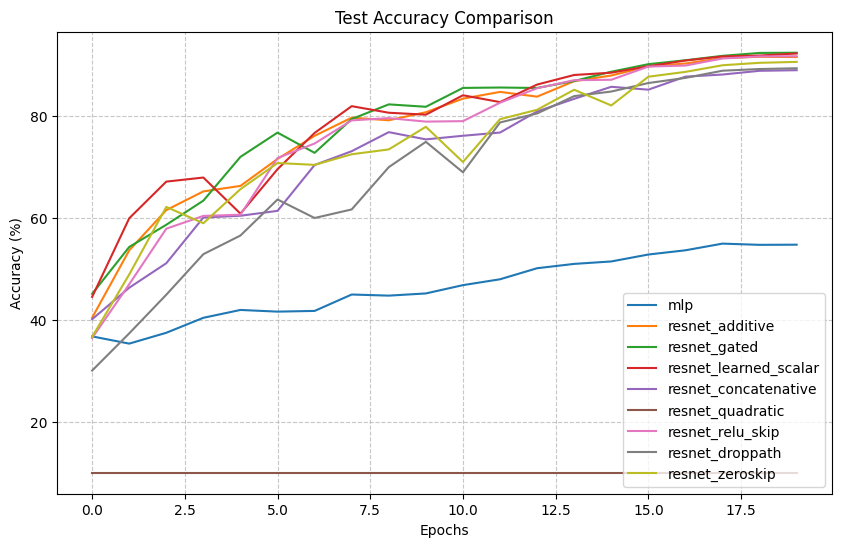

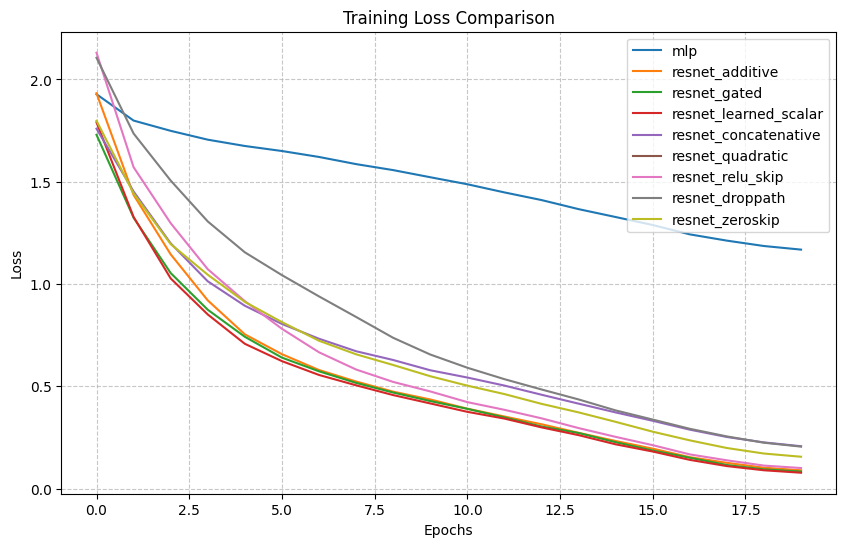

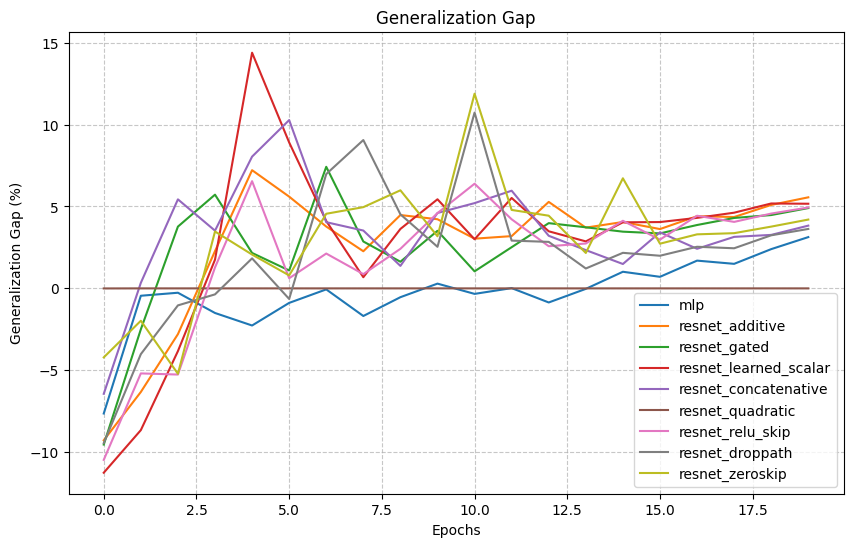

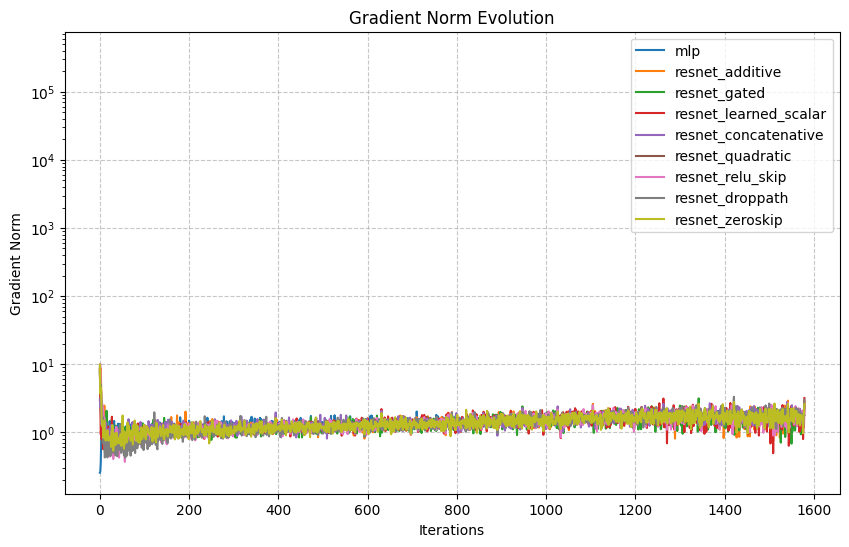

✅ mlp: 10000 valid samples for t-SNE.
✅ resnet_additive: 10000 valid samples for t-SNE.
✅ resnet_gated: 10000 valid samples for t-SNE.
✅ resnet_learned_scalar: 10000 valid samples for t-SNE.
✅ resnet_concatenative: 10000 valid samples for t-SNE.
⚠️ Skipping t-SNE for resnet_quadratic: all feature vectors contain NaN.
✅ resnet_relu_skip: 10000 valid samples for t-SNE.
✅ resnet_droppath: 10000 valid samples for t-SNE.
✅ resnet_zeroskip: 10000 valid samples for t-SNE.


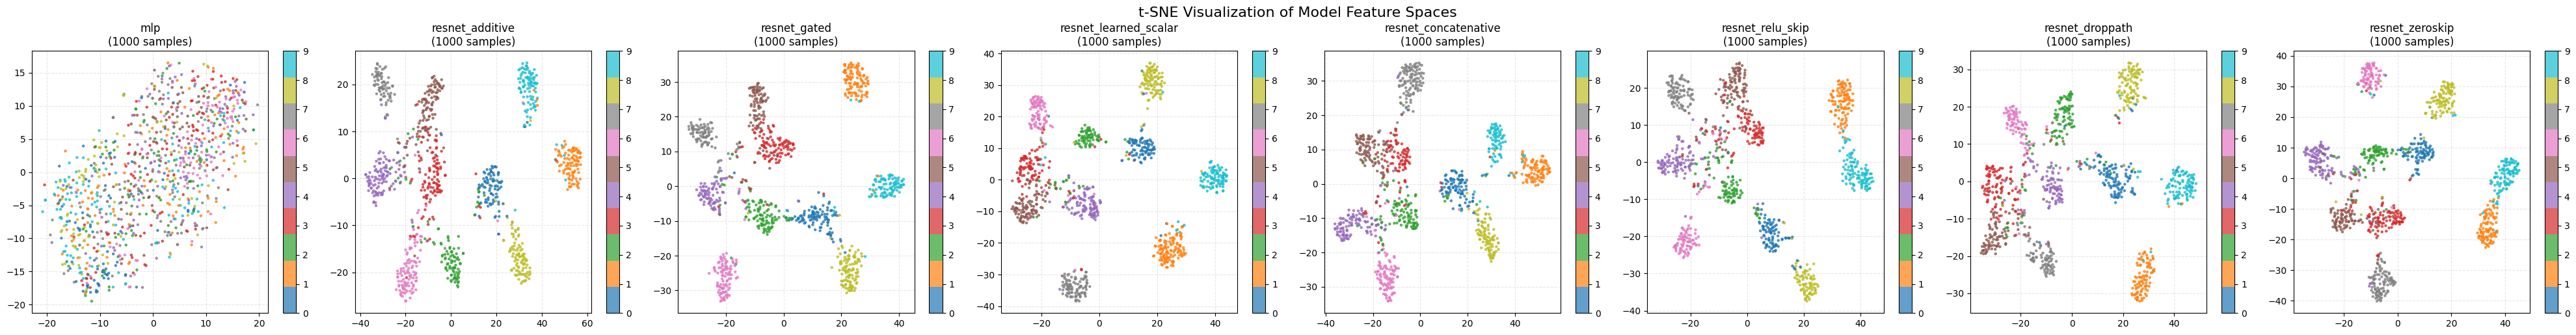

Results summary:


,model,final_test_acc,max_test_acc,final_train_acc,generalization_gap
2,resnet_gated,92.44,92.44,97.342,4.902
3,resnet_learned_scalar,92.29,92.29,97.456,5.166
6,resnet_relu_skip,91.75,91.75,96.686,4.936
1,resnet_additive,91.59,91.64,97.148,5.558
8,resnet_zeroskip,90.64,90.64,94.840,4.200
7,resnet_droppath,89.39,89.39,93.018,3.628
4,resnet_concatenative,89.01,89.01,92.840,3.830
0,mlp,54.76,54.97,57.890,3.130
5,resnet_quadratic,10.00,10.00,10.000,0.000


In [43]:
# Run full study
print("Starting skip-connection study...")
results_df, histories, features, targets, model_names = run_experiments(epoch_budget=20)
print("Results summary:")
display(results_df.sort_values('final_test_acc', ascending=False))

🚫 Excluding model: resnet_quadratic


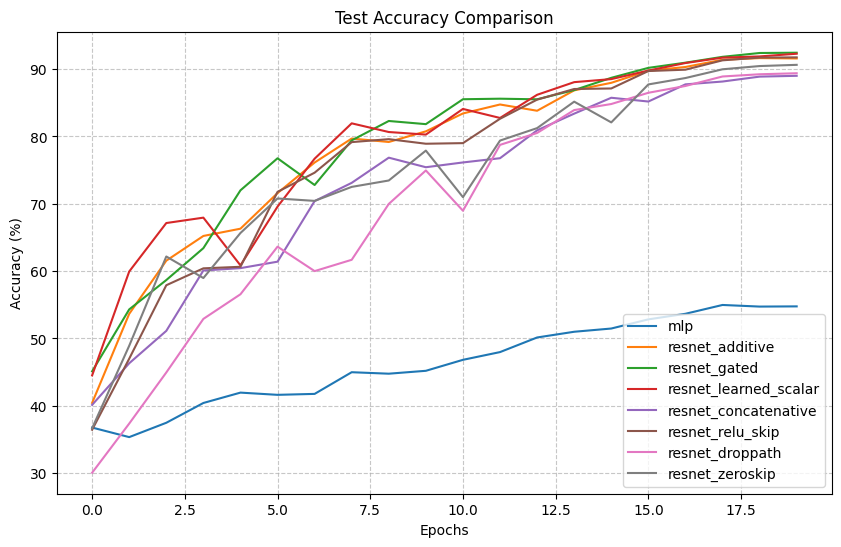

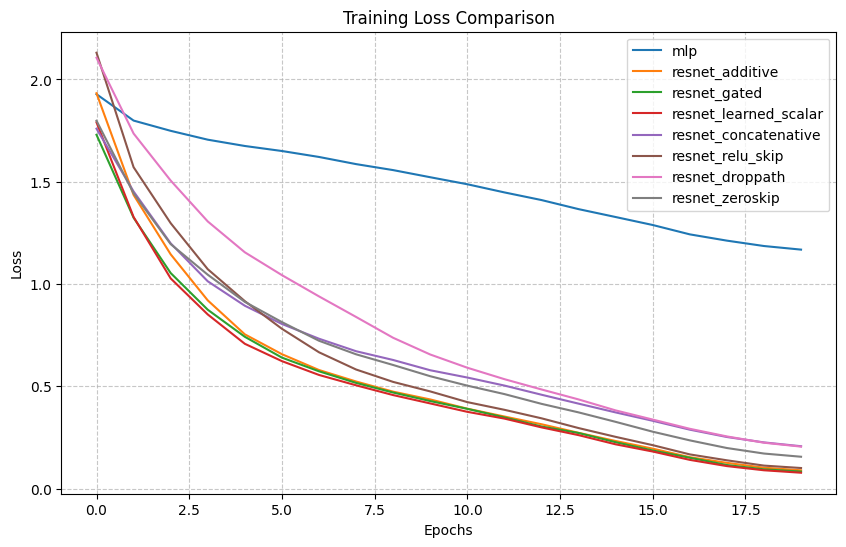

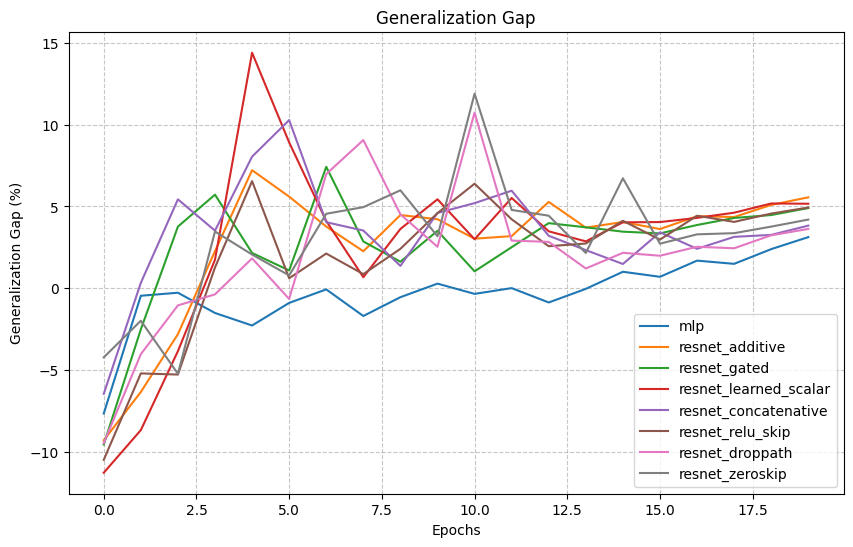

✅ mlp: 10000 valid samples for t-SNE.
✅ resnet_additive: 10000 valid samples for t-SNE.
✅ resnet_gated: 10000 valid samples for t-SNE.
✅ resnet_learned_scalar: 10000 valid samples for t-SNE.
✅ resnet_concatenative: 10000 valid samples for t-SNE.
✅ resnet_relu_skip: 10000 valid samples for t-SNE.
✅ resnet_droppath: 10000 valid samples for t-SNE.
✅ resnet_zeroskip: 10000 valid samples for t-SNE.


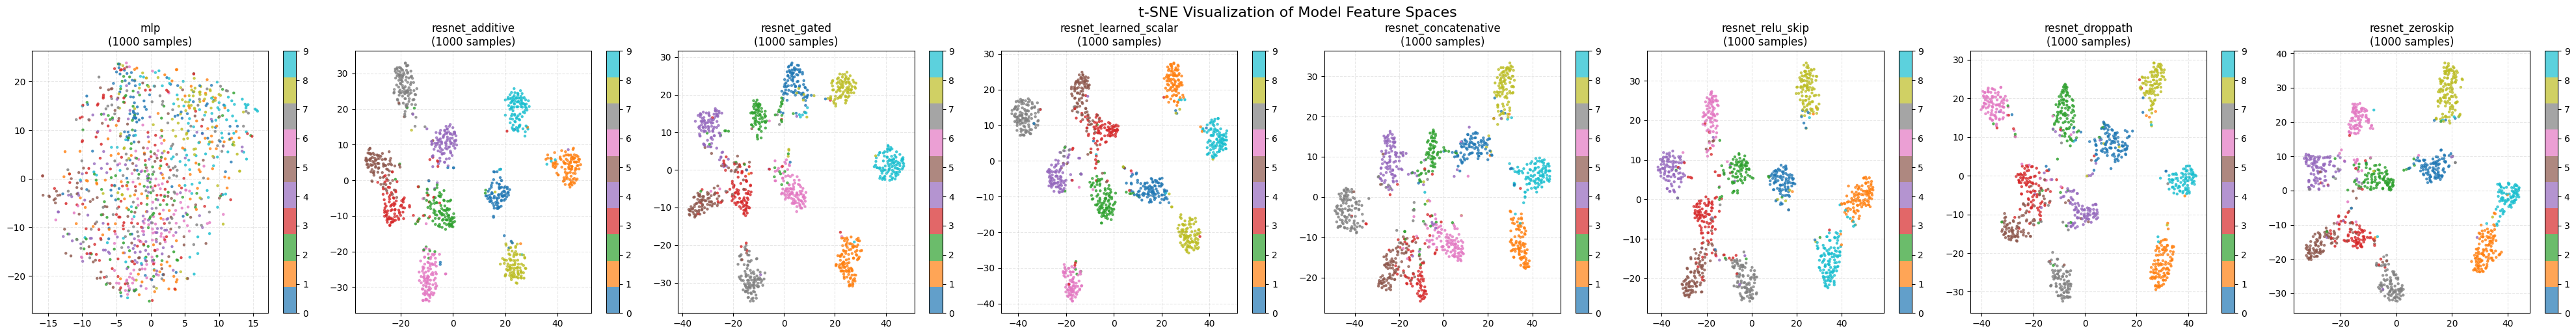

In [44]:
def filter_models(histories, features, targets, model_names, exclude_list):
    """
    Filters out models from the given lists based on model name substrings.

    Args:
        histories (List[Dict]): List of training history dicts
        features (List[np.ndarray]): Feature arrays
        targets (List[np.ndarray]): Target labels
        model_names (List[str]): Names of the models
        exclude_list (List[str]): List of substrings (model names) to remove

    Returns:
        Tuple of filtered (histories, features, targets, model_names)
    """
    filtered_histories = []
    filtered_features = []
    filtered_targets = []
    filtered_names = []

    for h, f, t, name in zip(histories, features, targets, model_names):
        if any(exclude in name for exclude in exclude_list):
            print(f"🚫 Excluding model: {name}")
            continue
        filtered_histories.append(h)
        filtered_features.append(f)
        filtered_targets.append(t)
        filtered_names.append(name)

    return filtered_histories, filtered_features, filtered_targets, filtered_names
exclude_models = ['resnet_quadratic']

filtered_histories, filtered_features, filtered_targets, filtered_names = filter_models(
    histories, features, targets, model_names, exclude_list=exclude_models
)

plot_accuracy(filtered_histories, filtered_names)
plot_loss(filtered_histories, filtered_names)
plot_generalization_gap(filtered_histories, filtered_names)
visualize_features_tsne(filtered_features, filtered_targets, filtered_names)

# 📉 Depth Ablation Study

In [45]:
# Ablation: Training depth study
def depth_ablation_study(skip_types=['additive', 'zeroskip'], depths=[5, 10, 18, 34], epochs=10):
    results = []

    for depth in depths:
        for skip_type in skip_types:
            print(f"\n=== Training ResNet-{depth} with {skip_type} skip ===")

            # Configure blocks based on depth
            if depth == 5:
                num_blocks = [1, 1, 1, 1]
            elif depth == 10:
                num_blocks = [1, 1, 1, 1]
            elif depth == 18:
                num_blocks = [2, 2, 2, 2]
            elif depth == 34:
                num_blocks = [3, 4, 6, 3]
            else:
                raise ValueError(f"Unsupported depth: {depth}")

            # Create and train model
            model = ResNetModel(BasicBlock, num_blocks, skip_type=skip_type)
            model = model.to(device)

            train_loader, test_loader = get_cifar10_loaders()
            criterion = nn.CrossEntropyLoss()
            optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
            scheduler = CosineAnnealingLR(optimizer, T_max=epochs)

            history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

            for epoch in range(1, epochs + 1):
                train_loss, train_acc, _ = train_epoch(
                    model, train_loader, criterion, optimizer, device, epoch,
                    track_gradients=False
                )

                test_loss, test_acc = evaluate(model, test_loader, criterion, device)
                scheduler.step()

                history['train_loss'].append(train_loss)
                history['train_acc'].append(train_acc)
                history['test_loss'].append(test_loss)
                history['test_acc'].append(test_acc)

                if epoch % 10 == 0:
                    print(f'Epoch {epoch}: Test Acc: {test_acc:.2f}%')

            # Record results
            results.append({
                'depth': depth,
                'skip_type': skip_type,
                'final_test_acc': test_acc,
                'final_train_acc': train_acc,
                'generalization_gap': train_acc - test_acc
            })

            # Clear output
            clear_output(wait=True)

    # Convert to DataFrame
    depth_results_df = pd.DataFrame(results)

    # Plot depth vs accuracy for different skip types
    plt.figure(figsize=(10, 6))
    for skip in skip_types:
        data = depth_results_df[depth_results_df['skip_type'] == skip]
        plt.plot(data['depth'], data['final_test_acc'], marker='o', label=f"{skip}")

    plt.title("Effect of Network Depth on Test Accuracy")
    plt.xlabel("Network Depth")
    plt.ylabel("Test Accuracy (%)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

    return depth_results_df

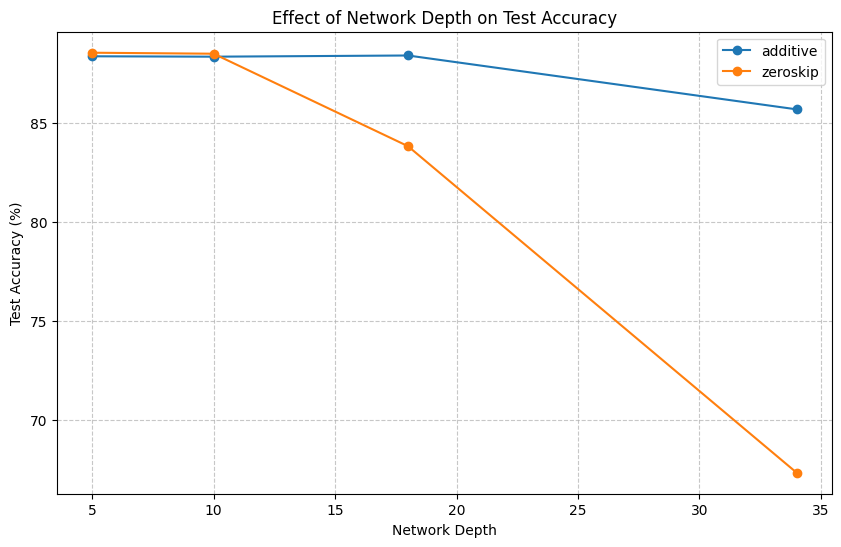

Depth study results:


,depth,skip_type,final_test_acc,final_train_acc,generalization_gap
0,5,additive,88.35,90.994,2.644
1,5,zeroskip,88.53,91.206,2.676
2,10,additive,88.33,90.838,2.508
3,10,zeroskip,88.48,91.180,2.700
4,18,additive,88.39,90.632,2.242
5,18,zeroskip,83.81,85.044,1.234
6,34,additive,85.67,86.972,1.302
7,34,zeroskip,67.32,66.528,-0.792


In [46]:
# Run depth ablation study
print("Starting depth ablation study...")
depth_results = depth_ablation_study(epochs=10)
print("Depth study results:")
display(depth_results)